In [258]:
import pandas as pd
import missingno

enc = 'utf-8'

In [259]:
data_path = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\conops_inference_pipeline\data'

In [260]:
YEAR = 2024

In [261]:
df_ext = pd.read_csv(f'{data_path}/ExtNord/CM_ExtNord_Timeline_{YEAR}_filled_cleaned.csv')
df_nord = pd.read_csv(f'{data_path}/Nord/CM_Nord_Timeline_{YEAR}_filled_cleaned.csv')

df_geo_ext = pd.read_csv(f'{data_path}/ExtNord/CM_ExtNord_Geomorphological.csv')
df_geo_nord = pd.read_csv(f'{data_path}/Nord/CM_Nord_Geomorphological.csv')

df_lc_ext = pd.read_csv(f'{data_path}/ExtNord/CM_ExtNord_Landcover_{YEAR}.csv')
df_lc_ext = df_lc_ext[['x', 'y', 'lc_type1']].copy()
df_lc_nord = pd.read_csv(f'{data_path}/Nord/CM_Nord_Landcover_{YEAR}.csv')
df_lc_nord = df_lc_nord[['x', 'y', 'lc_type1']].copy()

In [262]:
df_geo_ext.columns = df_geo_ext.columns.str.lower()
df_geo_nord.columns = df_geo_nord.columns.str.lower()

df_geo_ext['lon_rounded'] = df_geo_ext['x'].round(4)
df_geo_ext['lat_rounded'] = df_geo_ext['y'].round(4)

df_geo_nord['lon_rounded'] = df_geo_nord['x'].round(4)
df_geo_nord['lat_rounded'] = df_geo_nord['y'].round(4)

df_geo_ext.drop(columns=['x', 'y'], inplace=True)
df_geo_nord.drop(columns=['x', 'y'], inplace=True)

df_ext['lon_rounded'] = df_ext['longitude'].round(4)
df_ext['lat_rounded'] = df_ext['latitude'].round(4)

df_nord['lon_rounded'] = df_nord['longitude'].round(4)
df_nord['lat_rounded'] = df_nord['latitude'].round(4)

df_ext = pd.merge(df_ext, df_geo_ext, on=['lat_rounded', 'lon_rounded'], how='left')
df_nord = pd.merge(df_nord, df_geo_nord, on=['lat_rounded', 'lon_rounded'], how='left')

df_lc_ext['lon_rounded'] = df_lc_ext['x'].round(4)
df_lc_ext['lat_rounded'] = df_lc_ext['y'].round(4)

df_lc_nord['lon_rounded'] = df_lc_nord['x'].round(4)
df_lc_nord['lat_rounded'] = df_lc_nord['y'].round(4)

df_lc_ext.drop(columns=['x', 'y'], inplace=True)
df_lc_nord.drop(columns=['x', 'y'], inplace=True)

df_ext = pd.merge(df_ext, df_lc_ext, on=['lat_rounded', 'lon_rounded'], how='left')
df_nord = pd.merge(df_nord, df_lc_nord, on=['lat_rounded', 'lon_rounded'], how='left')

df_ext.drop(columns=['lat_rounded', 'lon_rounded', 
                     'div0_name', 'div0_code', 'div1_name', 'div2_name', 'div2_code', 'div3_name', 'div3_code','div4_name','div4_code','div5_name','div5_code',
                     'date','day','month_sin','month_cos',
                     'ndvi_mean','ndwi_mean','ndmi_mean','ndbi_mean','ndvi_std','ndwi_std','ndmi_std','ndbi_std',], inplace=True)

df_nord.drop(columns=['lat_rounded', 'lon_rounded', 
                     'div0_name', 'div0_code', 'div1_name', 'div2_name', 'div2_code', 'div3_name', 'div3_code','div4_name','div4_code','div5_name','div5_code',
                     'date','day','month_sin','month_cos',
                     'ndvi_mean','ndwi_mean','ndmi_mean','ndbi_mean','ndvi_std','ndwi_std','ndmi_std','ndbi_std',], inplace=True)

In [263]:
df_out = pd.concat([df_ext, df_nord])
df_out.reset_index(drop=True, inplace=True)

In [264]:
agg = {
    # dynamic
    "ndvi": "mean",
    "ndwi": "mean",
    "ndmi": "mean",
    "ndbi": "mean",
    "lst_day": "mean",
    "lst_night": "mean",
    "lst": "mean",
    "precipitation": "sum",

    # static
    "distance_to_coast": "first",
    "distance_to_river": "first",
    "slope_mean_1km": "first",
    "aspect_mean_200m": "first",
    "elevation_mean_1km": "first",
    "hillshade_mean_1km": "first",
    "fs_area_1km": "first",
    "flow_accu_200m": "first",
    "lc_type1": "first",
}

df_out = (df_out.groupby(['point_code', 'latitude', 'longitude', 'div1_code', 'year', 'month'], as_index=False).agg(agg))

<Axes: >

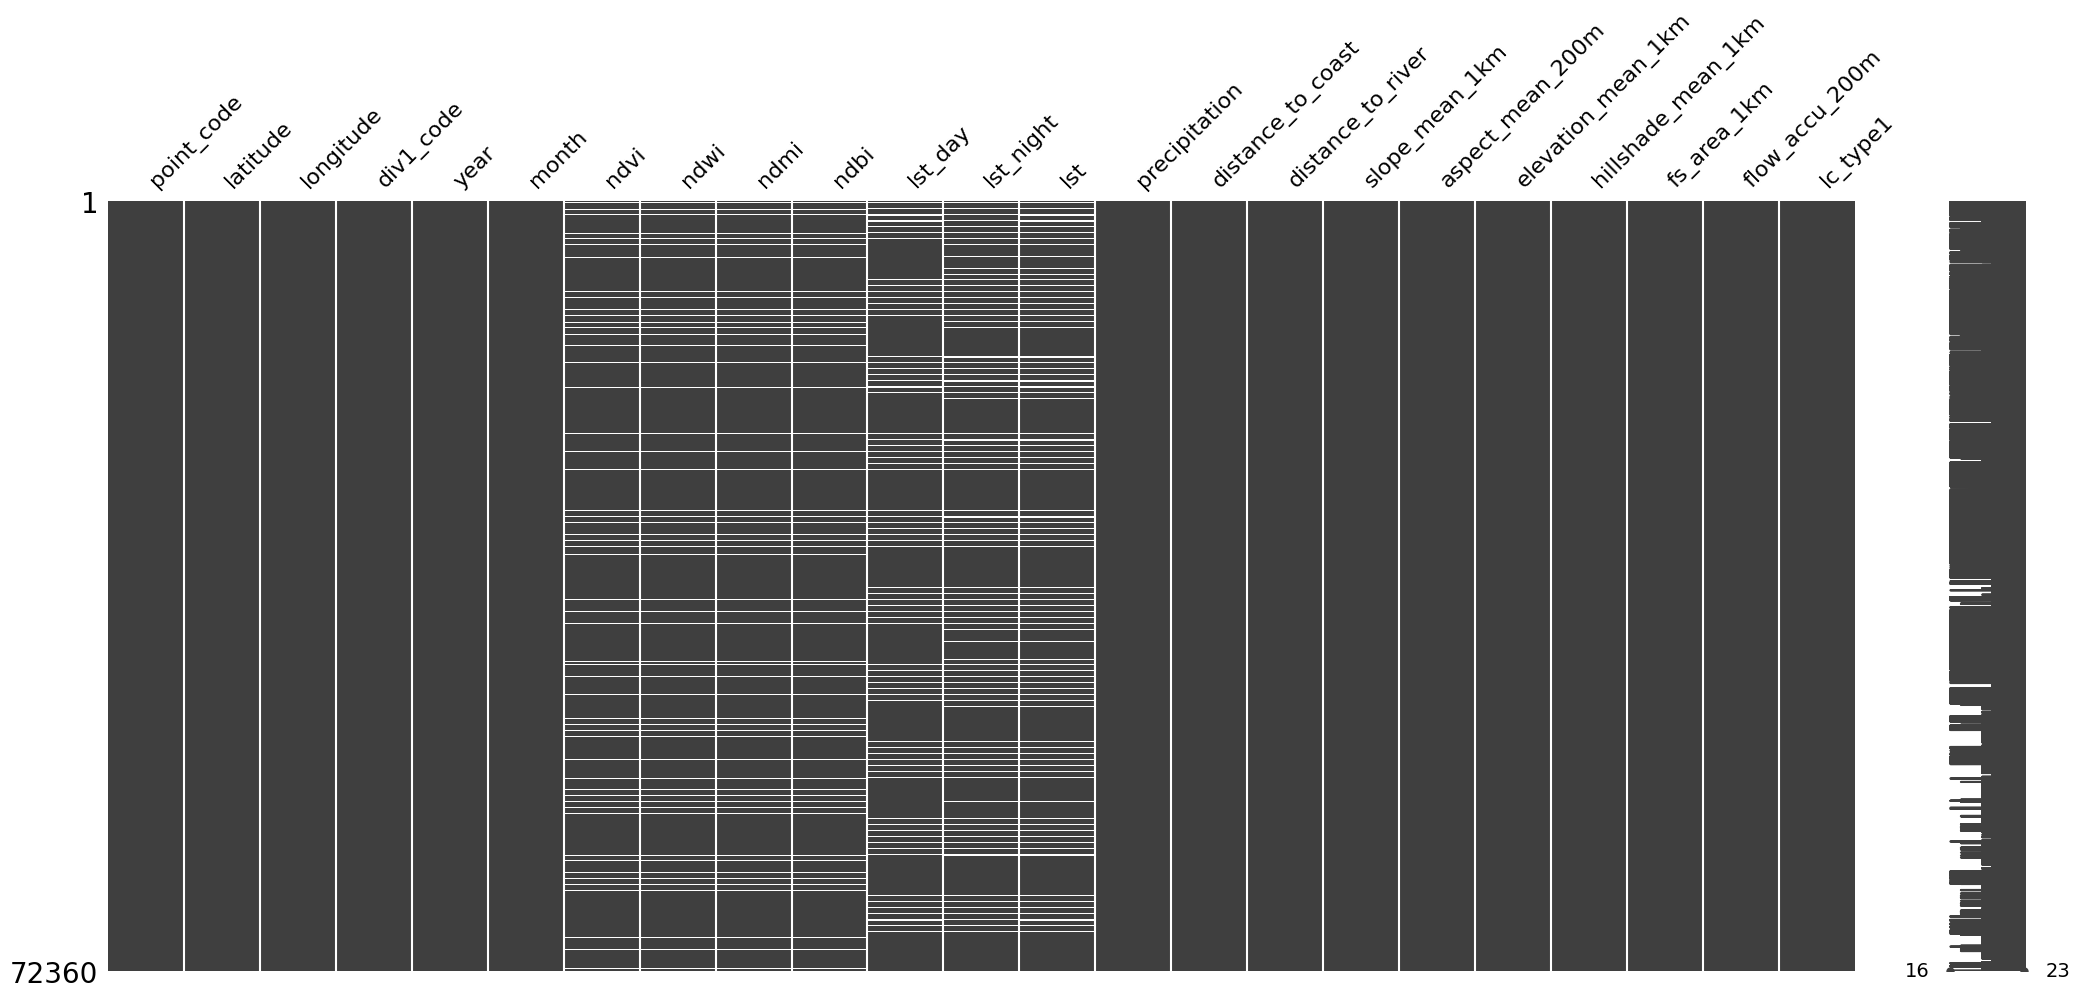

In [265]:
missingno.matrix(df_out)

In [266]:
df_out

,point_code,latitude,longitude,div1_code,year,month,ndvi,ndwi,ndmi,ndbi,...,precipitation,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_type1
0,04BIB0100001,9.22586,13.74124,NOR,2024,1,0.183911,-0.322584,-0.189613,0.189613,...,0.000000,7698.446849,1008.157187,1,240.246838,218.610308,182.910086,0.0,2.473634,12
1,04BIB0100001,9.22586,13.74124,NOR,2024,2,0.135448,-0.242438,-0.202781,0.202781,...,2.900000,7698.446849,1008.157187,1,240.246838,218.610308,182.910086,0.0,2.473634,12
2,04BIB0100001,9.22586,13.74124,NOR,2024,3,0.203810,-0.401006,-0.181389,0.181389,...,10.750000,7698.446849,1008.157187,1,240.246838,218.610308,182.910086,0.0,2.473634,12
3,04BIB0100001,9.22586,13.74124,NOR,2024,4,0.129228,-0.258287,-0.243779,0.243779,...,39.069999,7698.446849,1008.157187,1,240.246838,218.610308,182.910086,0.0,2.473634,12
4,04BIB0100001,9.22586,13.74124,NOR,2024,5,0.114636,-0.224643,-0.260729,0.260729,...,84.839998,7698.446849,1008.157187,1,240.246838,218.610308,182.910086,0.0,2.473634,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72355,09YAG110000D,10.31224,15.28186,EXT,2024,8,0.433152,-0.328282,0.113077,-0.113077,...,673.719985,22599.938104,212.065258,1,152.602122,329.523033,180.283980,0.0,142.477396,12
72356,09YAG110000D,10.31224,15.28186,EXT,2024,9,0.270393,-0.298694,-0.057335,0.057335,...,277.279993,22599.938104,212.065258,1,152.602122,329.523033,180.283980,0.0,142.477396,12
72357,09YAG110000D,10.31224,15.28186,EXT,2024,10,0.446750,-0.425640,0.044882,-0.044882,...,160.509997,22599.938104,212.065258,1,152.602122,329.523033,180.283980,0.0,142.477396,12
72358,09YAG110000D,10.31224,15.28186,EXT,2024,11,0.413458,-0.426638,0.009444,-0.009444,...,0.000000,22599.938104,212.065258,1,152.602122,329.523033,180.283980,0.0,142.477396,12


In [267]:
df_out.to_csv(f'../../data/Ecoregions/CM_Timeline_{YEAR}.csv', index=False, encoding=enc)